# 04 — MPI Strong Scaling

**Strong scaling**: fixed problem size, increase MPI process count.

Ideal speedup: $S(p) = p$.  
Real speedup is bounded by **Amdahl's law**:
$$T(p) = T_1 \left[ f + \frac{1-f}{p} \right], \quad
S(p) = \frac{1}{f + (1-f)/p}$$
where $f$ is the serial fraction (communication + setup overhead).

The parallel efficiency $\eta(p) = S(p)/p$ should stay above 70–80% for good scaling.

Data from `results/scaling.csv` (generated by `scripts/scaling_sweep.py`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    from scipy.optimize import curve_fit
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False

plt.rcParams.update({
    'font.size': 12, 'figure.dpi': 130,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})
DATA = Path('../results')

try:
    df = pd.read_csv(DATA / 'scaling.csv')
    print(df.to_string(index=False))
except FileNotFoundError:
    print('Run scripts/scaling_sweep.py first')
    df = pd.DataFrame()

 ranks  wall_time  speedup  efficiency
     1     23.683 1.000000  100.000000
     2     13.206 1.793352   89.667575
     4      8.725 2.714384   67.859599


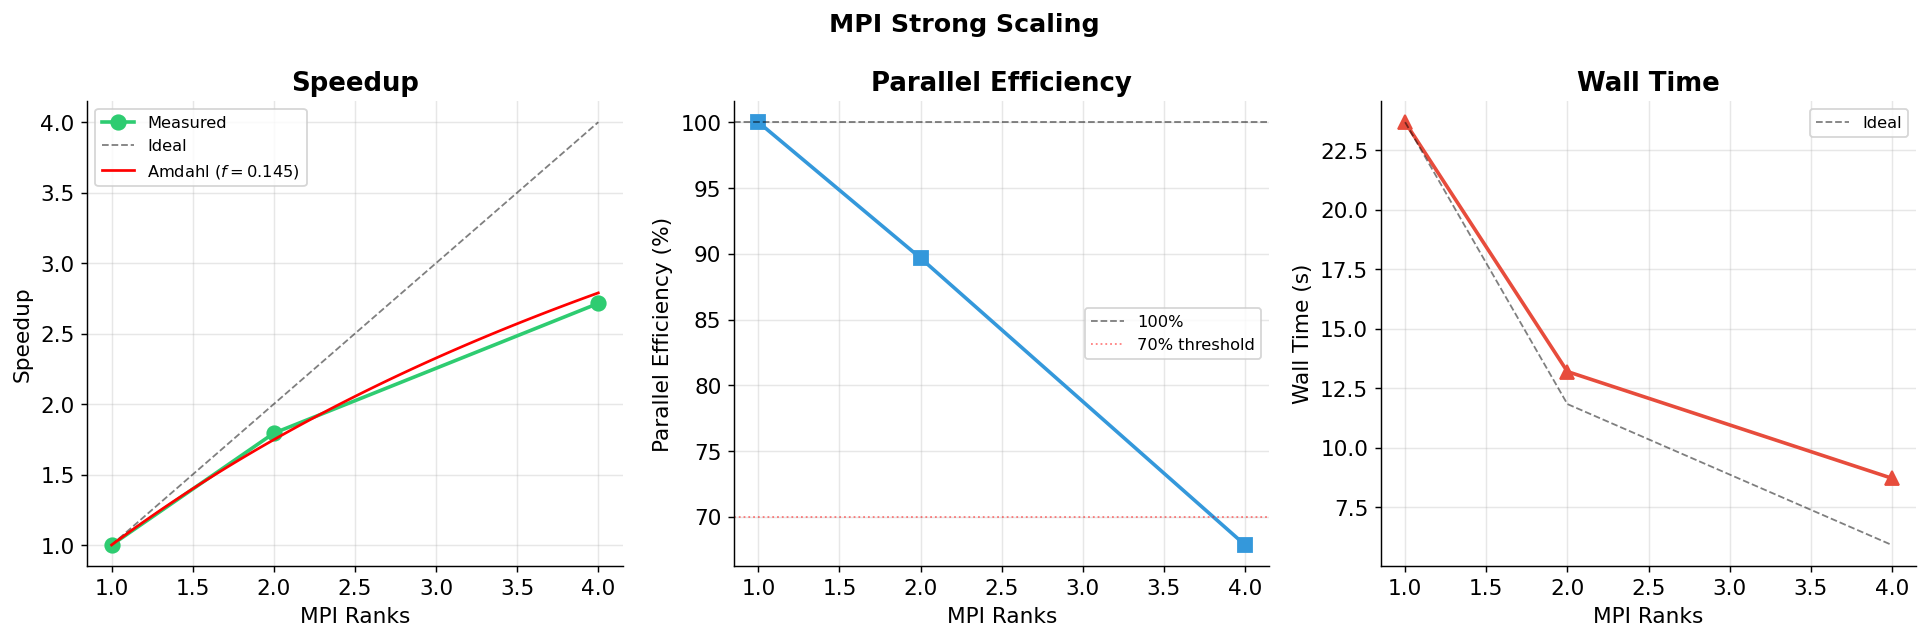

Saved scaling.png

Amdahl serial fraction: 0.1448 (14.48%)
Theoretical max speedup: 6.9x


In [2]:
if not df.empty:
    T1 = df[df['ranks'] == df['ranks'].min()]['wall_time'].values[0]

    # Amdahl fit
    f_serial = None
    if HAS_SCIPY and len(df) >= 3:
        def amdahl_T(p, f): return T1 * (f + (1 - f) / p)
        try:
            popt, _ = curve_fit(amdahl_T, df['ranks'].values,
                                df['wall_time'].values,
                                p0=[0.05], bounds=(0, 0.5))
            f_serial = popt[0]
        except Exception as e:
            print(f'Amdahl fit failed: {e}')

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Speedup
    ax = axes[0]
    ax.plot(df['ranks'], df['speedup'], 'o-', color='#2ecc71', lw=2, ms=8,
            label='Measured')
    ax.plot(df['ranks'], df['ranks'],   'k--', lw=1, alpha=0.5, label='Ideal')
    if f_serial is not None:
        ps = np.linspace(df['ranks'].min(), df['ranks'].max(), 100)
        S_amdahl = T1 / amdahl_T(ps, f_serial)
        ax.plot(ps, S_amdahl, 'r-', lw=1.5,
                label=f'Amdahl ($f={f_serial:.3f}$)')
    ax.set_xlabel('MPI Ranks')
    ax.set_ylabel('Speedup')
    ax.set_title('Speedup', fontweight='bold')
    ax.legend(fontsize=9)

    # Efficiency
    ax = axes[1]
    ax.plot(df['ranks'], df['efficiency'], 's-', color='#3498db', lw=2, ms=8)
    ax.axhline(100, color='k', ls='--', lw=1, alpha=0.5, label='100%')
    ax.axhline(70,  color='r', ls=':',  lw=1, alpha=0.5, label='70% threshold')
    ax.set_xlabel('MPI Ranks')
    ax.set_ylabel('Parallel Efficiency (%)')
    ax.set_title('Parallel Efficiency', fontweight='bold')
    ax.legend(fontsize=9)

    # Wall time
    ax = axes[2]
    ax.plot(df['ranks'], df['wall_time'], '^-', color='#e74c3c', lw=2, ms=8)
    # Ideal scaling reference
    ax.plot(df['ranks'], T1 / df['ranks'], 'k--', lw=1, alpha=0.5, label='Ideal')
    ax.set_xlabel('MPI Ranks')
    ax.set_ylabel('Wall Time (s)')
    ax.set_title('Wall Time', fontweight='bold')
    ax.legend(fontsize=9)

    plt.suptitle('MPI Strong Scaling', fontweight='bold', fontsize=14)
    plt.tight_layout()
    plt.savefig(DATA / 'scaling.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved scaling.png')

    if f_serial is not None:
        print(f'\nAmdahl serial fraction: {f_serial:.4f} ({f_serial*100:.2f}%)')
        print(f'Theoretical max speedup: {1/f_serial:.1f}x')